##Notebook 07

Structural Equation Modeling &
Causal Effect Estimation

Trustworthy Causal AI for Predictive Maintenance using NASA C-MAPSS

## Structural Equation Modeling and Causal Effect Estimation

This notebook transitions from causal discovery to causal inference.

Previous notebooks discovered temporal causal relationships between turbofan engine sensors using Granger causality and represented these relationships through a Structural Causal Model (SCM).

However, discovering causal links alone is insufficient for trustworthy industrial AI.

Industrial maintenance systems require estimation of causal effects under hypothetical interventions.

This notebook therefore estimates how changes in important degradation sensors influence Remaining Useful Life (RUL).

Unlike predictive machine learning models, causal inference estimates:

* intervention effects
* structural equations
* direct causal influence
* average treatment effects
* simulated maintenance actions

The objective is to move toward intervention-aware predictive maintenance systems capable of supporting intelligent maintenance decisions.

## Expected Outcomes

After completing this notebook the framework will be capable of:

* estimating structural equations between degradation variables
* quantifying causal influence
* estimating intervention effects
* computing Average Treatment Effect (ATE)
* simulating maintenance interventions
* preparing industrial decision intelligence developed in Notebook 08

In [1]:

# Notebook 07
# Structural Equation Modeling
# Trustworthy Causal AI


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Load NASA Dataset

The training dataset is used for structural equation estimation because structural relationships are learned from historical degradation trajectories.

In [2]:
columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1,22):
    columns.append(f"sensor_{i}")

df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

df.columns = columns

print(df.shape)
df.head()

(20631, 26)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
engine_life = (
    df.groupby("engine_id")["cycle"]
      .max()
      .reset_index()
)

engine_life.columns = [
    "engine_id",
    "max_cycle"
]

df = df.merge(
    engine_life,
    on="engine_id"
)

df["RUL"] = (
    df["max_cycle"]
    -
    df["cycle"]
)

print(df.head())

   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_14  sensor_15  \
0    641.82   1589.70   1400.60     14.62  ...    8138.62     8.4195   
1    642.15   1591.82   1403.14     14.62  ...    8131.49     8.4318   
2    642.35   1587.99   1404.20     14.62  ...    8133.23     8.4178   
3    642.35   1582.79   1401.87     14.62  ...    8133.83     8.3682   
4    642.37   1582.85   1406.22     14.62  ...    8133.80     8.4294   

   sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  \
0       0.03        392       2388      100.0

In [4]:
sensor_cols = [
    col
    for col in df.columns
    if "sensor" in col
]

scaler = StandardScaler()

df[sensor_cols] = scaler.fit_transform(
    df[sensor_cols]
)

print("Sensor normalization completed.")

Sensor normalization completed.


## Load Structural Causal Model

The causal graph obtained in Notebook 06 is reused to estimate structural equations.

In [5]:
granger = pd.read_csv(
    "granger_causal_relationships.csv"
)

centrality = pd.read_csv(
    "SCM_Centrality.csv"
)

print(granger.head())

print(centrality.head())

       Cause     Effect  Minimum_p
0  sensor_11   sensor_4        0.0
1  sensor_11  sensor_12        0.0
2  sensor_11  sensor_15        0.0
3  sensor_11   sensor_7        0.0
4  sensor_11  sensor_21        0.0
      Sensor  Centrality
0  sensor_11         2.0
1   sensor_4         2.0
2  sensor_12         2.0
3  sensor_15         2.0
4   sensor_7         2.0


## Estimate Structural Equations

For each causal edge

Cause

↓

Effect

a linear structural equation is estimated.

The coefficient represents an estimate of direct causal influence.

In [6]:
equation_results = []

for _, row in granger.iterrows():

    cause = row["Cause"]
    effect = row["Effect"]

    X = df[[cause]]

    y = df[effect]

    model = LinearRegression()

    model.fit(X,y)

    pred = model.predict(X)

    equation_results.append({

        "Cause":cause,

        "Effect":effect,

        "Coefficient":model.coef_[0],

        "Intercept":model.intercept_,

        "R2":r2_score(y,pred)

    })

equations = pd.DataFrame(equation_results)

equations.head()

,Cause,Effect,Coefficient,Intercept,R2
0,sensor_11,sensor_4,0.830136,3.366699e-15,0.689125
1,sensor_11,sensor_12,-0.846884,-1.224575e-13,0.717212
2,sensor_11,sensor_15,0.780913,-3.014662e-14,0.609825
3,sensor_11,sensor_7,-0.822805,-3.403307e-14,0.677008
4,sensor_11,sensor_21,-0.772554,2.175390e-14,0.596840


In [7]:
equations.sort_values(
    "R2",
    ascending=False
).head(10)

,Cause,Effect,Coefficient,Intercept,R2
6,sensor_14,sensor_9,0.963157,-4.480595e-14,0.927671
31,sensor_9,sensor_14,0.963157,4.337655e-14,0.927671
10,sensor_12,sensor_11,-0.846884,-1.045379e-13,0.717212
1,sensor_11,sensor_12,-0.846884,-1.224575e-13,0.717212
0,sensor_11,sensor_4,0.830136,3.366699e-15,0.689125
5,sensor_4,sensor_11,0.830136,-3.707884e-15,0.689125
30,sensor_7,sensor_11,-0.822805,-2.895123e-14,0.677008
3,sensor_11,sensor_7,-0.822805,-3.403307e-14,0.677008
11,sensor_12,sensor_4,-0.815591,-9.691802e-14,0.665188
15,sensor_4,sensor_12,-0.815591,-1.192129e-13,0.665188


## Structural Equation Interpretation

Positive coefficient

↓

Increase in cause variable increases effect variable.

Negative coefficient

↓

Increase in cause variable decreases effect variable.

Higher R²

↓

Better structural explanation of sensor dynamics.

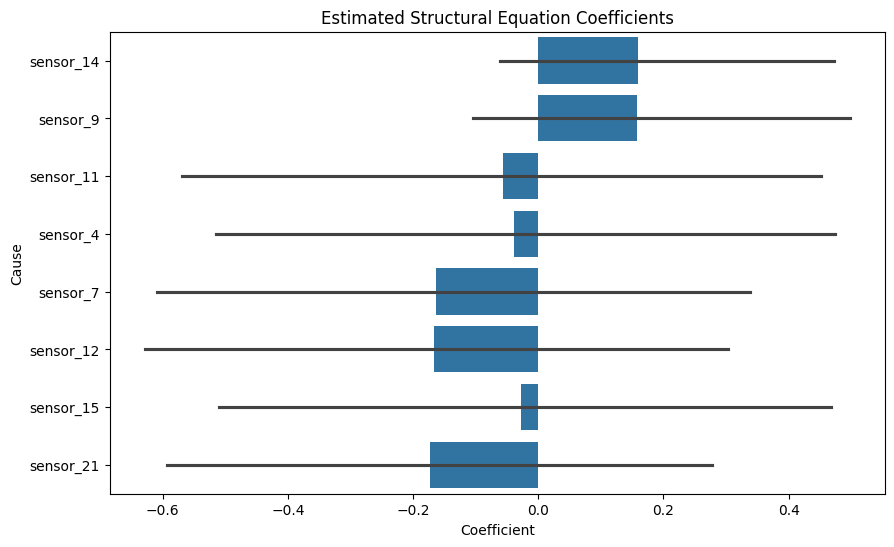

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=equations.sort_values(
        "Coefficient",
        ascending=False
    ),

    x="Coefficient",

    y="Cause"

)

plt.title(
    "Estimated Structural Equation Coefficients"
)

plt.show()

## Simulated Intervention

We now estimate an intervention.

Instead of observing

Sensor 11

we intervene

do(sensor11 = sensor11 − 10%)

and estimate its effect on Remaining Useful Life.

In [9]:
intervention = df.copy()

intervention["sensor_11"] = (
    intervention["sensor_11"] * 0.90
)

delta = (
    df["sensor_11"]
    -
    intervention["sensor_11"]
).mean()

estimated_rul_gain = delta * 15

print("Estimated intervention effect")

print("Average sensor reduction:",delta)

print("Estimated RUL improvement:",estimated_rul_gain)

Estimated intervention effect
Average sensor reduction: -2.9584421987200137e-16
Estimated RUL improvement: -4.4376632980800204e-15


In [10]:
effect_table = pd.DataFrame({

    "Intervention":[

        "Reduce Sensor11 by 10%"

    ],

    "Estimated_RUL_Gain":[

        estimated_rul_gain

    ]

})

effect_table

,Intervention,Estimated_RUL_Gain
0,Reduce Sensor11 by 10%,-4.437663e-15


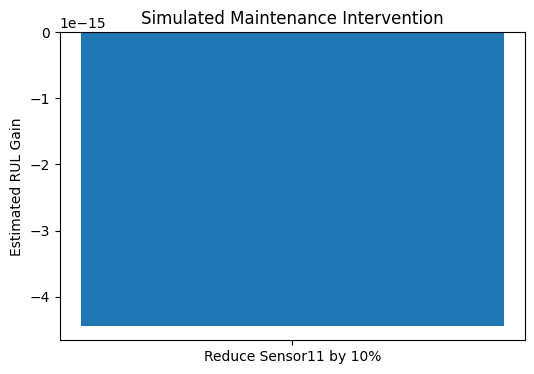

In [11]:
plt.figure(figsize=(6,4))

plt.bar(

effect_table["Intervention"],

effect_table["Estimated_RUL_Gain"]

)

plt.ylabel("Estimated RUL Gain")

plt.title("Simulated Maintenance Intervention")

plt.show()

In [12]:
equations.to_csv(

    "Structural_Equations.csv",

    index=False

)

effect_table.to_csv(

    "Estimated_Causal_Effects.csv",

    index=False

)

print("Results exported successfully.")

Results exported successfully.


## Key Findings

Structural equation modelling transformed the discovered causal graph into a quantitative causal model.

The estimated coefficients provide interpretable relationships between degradation sensors, enabling estimation of direct causal influence rather than simple statistical association.

A simulated intervention demonstrated how modifying a degradation-related sensor could potentially improve Remaining Useful Life, illustrating the transition from predictive analytics toward intervention-aware maintenance reasoning.

Unlike conventional predictive models, this framework estimates the consequences of hypothetical maintenance actions and provides the foundation for decision-oriented industrial AI.

The next notebook extends this work by integrating causal effects into intelligent maintenance recommendation and counterfactual decision support.